# One electron on three sites — FCI vs free projection vs constrained path

A Hubbard model with an arbitrary (symmetric) hopping matrix and a single electron,

$$
t=\begin{pmatrix}-0.67 & 0.96 & 0.52\\ 0.96 & -0.19 & 0.39\\ 0.52 & 0.39 & 0.03\end{pmatrix},
\qquad U = 10, \qquad n_{\rm elec} = (1,0).
$$

Every AFQMC walker is a single Slater determinant with one occupied orbital, i.e. a real
three-component ray.  On the unit sphere that is two angles,

$$
|\phi\rangle=\sin\theta\cos\varphi\,|100\rangle+\sin\theta\sin\varphi\,|010\rangle+\cos\theta\,|001\rangle ,
$$

the three-site generalisation of the $(\cos\alpha,\sin\alpha)$ walker of
`fp_hubbard_1e2s.ipynb` and of its two-channel product
$(\cos\alpha,\sin\alpha)\otimes(\cos\beta,\sin\beta)$ in `fp_hubbard_2e2s.ipynb`.

**Why $U=10$ still matters.**  One electron never meets a second one, so
$U\,n_\uparrow n_\downarrow$ contributes nothing to the exact Hamiltonian: in this CI basis
$H = h_1$, and FCI $=$ UHF $=$ the lowest eigenvector of $h_1$.  The sampler does not get
that for free.  The Hubbard–Stratonovich transform still puts a fluctuating auxiliary
field on every site, so each walker is kicked around at strength $\sqrt{U\,\delta\tau}$ and
only the *average* over fields collapses back onto the $h_1$ ground state.  Any deviation
below is therefore sampling error or the constrained-path bias — never physics.

## 1.  The model and its mean field

In [1]:
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from pyscf import fci

import hubbard

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

NSITE = 3
NELEC = (1, 0)          # one alpha electron
U     = 10.0
T     = np.array([[-0.67,  0.96, 0.52],
                  [ 0.96, -0.19, 0.39],
                  [ 0.52,  0.39, 0.03]])

# `h1=` overrides the nearest-neighbour chain with this explicit hopping matrix.
h1, eri, mol, mf = hubbard.hubbard_mf(NSITE, None, U, NELEC, h1=T, verbose=0)

print("h1 =\n", h1)
print("\none-particle levels :", np.linalg.eigvalsh(h1))
print("E(UHF)             = %+.10f" % mf.e_tot)

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-31-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu
h1 =
 [[-0.67  0.96  0.52]
 [ 0.96 -0.19  0.39]
 [ 0.52  0.39  0.03]]

one-particle levels : [-1.442165 -0.3673    0.979465]
E(UHF)             = -1.4421646329


## 2.  FCI

With one electron the determinant basis is just the three sites, $\{|100\rangle,|010\rangle,|001\rangle\}$,
so FCI is the lowest eigenvector of $h_1$.  We fix the overall sign (a determinant is a ray)
by demanding $c_1>0$.

In [2]:
e_fci, ci = fci.direct_spin1.kernel(h1, eri, NSITE, NELEC)

c_fci = np.asarray(ci).ravel()
c_fci = c_fci * np.sign(c_fci[0])                 # gauge: first component positive
th_fci, ph_fci = hubbard.angles_of(c_fci)

print("E(FCI)          = %+.10f" % e_fci)
print("E(FCI) - E(UHF) = %+.2e   (zero: one electron never sees U)" % (e_fci - mf.e_tot))
print("\nFCI CI coefficients   c = (%+.6f, %+.6f, %+.6f)" % tuple(c_fci))
print("as angles             theta = %+.6f   phi = %+.6f" % (th_fci, ph_fci))

# round trip through the sphere parametrisation
def from_angles(theta, phi):
    "(sin t cos p, sin t sin p, cos t) -- the walker parametrisation of this notebook."
    theta, phi = np.asarray(theta), np.asarray(phi)
    return np.stack([np.sin(theta) * np.cos(phi),
                     np.sin(theta) * np.sin(phi),
                     np.cos(theta)], axis=-1)

print("rebuilt from angles     ", from_angles(th_fci, ph_fci))
print("max |rebuilt - c|      = %.2e" % np.abs(from_angles(th_fci, ph_fci) - c_fci).max())

E(FCI)          = -1.4421646329
E(FCI) - E(UHF) = -2.22e-16   (zero: one electron never sees U)

FCI CI coefficients   c = (+0.806081, -0.576922, -0.131889)
as angles             theta = +1.703071   phi = -0.621193
rebuilt from angles      [ 0.806081 -0.576922 -0.131889]
max |rebuilt - c|      = 1.11e-16


In [3]:
print("uhf mo coeff")
print(mf.mo_coeff[0][:,:1])

uhf mo coeff
[[ 0.806081]
 [-0.576922]
 [-0.131889]]


In [4]:
# mo_a = np.array([[1.0], [0.0], [0.0]])     # |100>
# mo_b = np.zeros((NSITE, 0))                # beta channel empty

mo_a = mf.mo_coeff[0][:,:NELEC[0]]         # Exact
mo_b = np.zeros((NSITE, 0))                # beta channel empty

qmc = hubbard.afqmc_setup(h1, U, NELEC, mo_a, mo_b, NSITE)
v_T = qmc.ci_trial

print("trial CI vector       :", v_T)
print("<Psi_T|Psi_FCI>       = %+.6f" % (v_T @ c_fci))
print("<Psi_T|H|Psi_T>       = %+.6f   (FCI: %+.6f)" % (v_T @ h1 @ v_T, e_fci))

trial CI vector       : [ 0.806081 -0.576922 -0.131889]
<Psi_T|Psi_FCI>       = +1.000000
<Psi_T|H|Psi_T>       = -1.442165   (FCI: -1.442165)


## 4.  Exact imaginary-time reference

Before sampling anything, project the trial deterministically:
$|\Psi(\tau)\rangle \propto e^{-\tau H}|\Psi_T\rangle$.  This is what an infinitely
well-sampled free projection must reproduce, coefficient by coefficient.

In [5]:
def exact_projection(H, v0, taus):
    """Normalised e^{-tau H} v0, sign-fixed on the first component, for each tau."""
    w, V = np.linalg.eigh(H)
    out = []
    for tau in np.atleast_1d(taus):
        v = V @ (np.exp(-tau * w) * (V.T @ v0))
        v = v / np.linalg.norm(v)
        out.append(v * np.sign(v[0]))
    return np.array(out)

tau_grid = np.linspace(0.0, 4.0, 201)
c_exact  = exact_projection(h1, v_T, tau_grid)
e_exact  = hubbard.exact_mixed_estimator(h1, v_T, v_T, tau_grid)

for tau in (0.0, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0):
    c = exact_projection(h1, v_T, [tau])[0]
    print("tau = %4.1f   c = (%+.6f, %+.6f, %+.6f)   E_mix = %+.6f"
          % (tau, c[0], c[1], c[2],
             hubbard.exact_mixed_estimator(h1, v_T, v_T, [tau])[0]))
print("\nFCI          c = (%+.6f, %+.6f, %+.6f)   E     = %+.6f" % (*c_fci, e_fci))

tau =  0.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  0.5   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  1.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  2.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  4.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  6.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165
tau =  8.0   c = (+0.806081, -0.576922, -0.131889)   E_mix = -1.442165

FCI          c = (+0.806081, -0.576922, -0.131889)   E     = -1.442165


## 5.  Free-projection AFQMC

No force bias and no constraint, so free projection is exact up to the time step and the
statistics.  `snap_every` stores the walker population every 10 blocks; each snapshot is
turned back into a CI vector by
$|\Psi\rangle=\sum_w W_w |\phi_w\rangle$ (no importance sampling, so no overlap to divide
out), and snapshots at the same $\tau$ are combined across trajectories by their
accumulated amplitude.

In [6]:
fp = hubbard.run_free_projection(
        qmc, dt=0.001, n_walkers=1000, n_prop_steps=50, n_blocks=80,
        n_traj=100, seed=0, n_exp_terms=10, sr_every=20,
        snap_every=10, verbose=2)


Free projection | trajectories 1-1 of 100 | 5.2 s
     tau   amplitude      Energy      Error     ESS
    0.00   1.000e+00    -1.44216        N/A     1.0
    0.50   1.038e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.71077  phi = -0.65635   c = (+0.7845, -0.6043, -0.1395)   E_var = -1.439314
    1.00   1.121e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.64926  phi = -0.69596   c = (+0.7651, -0.6392, -0.0784)   E_var = -1.431782
    1.50   1.153e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.68158  phi = -0.66265   c = (+0.7835, -0.6114, -0.1106)   E_var = -1.439190
    2.00   1.151e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.74921  phi = -0.66055   c = (+0.7771, -0.6038, -0.1775)   E_var = -1.433729
    2.50   1.089e+00    -1.44216        N/A     1.0
        |Psi> :  theta = +1.71584  phi = -0.65381   c = (+0.7854, -0.6018, -0.1445)   E_var = -1.439319
    3.00   1.022e+00    -1.44216        N/A     1.0
        |Psi>

In [7]:
# CI coefficients as a function of imaginary time, alongside the exact projection.
fp_taus = fp.snap_taus()
fp_wfn  = {tau: hubbard.wavefunction(fp.snaps_at(tau), qmc.ci_hamiltonian, v_T)
           for tau in fp_taus}

print("free projection:  reconstructed CI coefficients  (exact e^{-tau H}|Psi_T> beneath)")
print("  %5s   %-24s %-24s %-24s   %10s" % ("tau", "c1", "c2", "c3", "E_var"))
for tau in fp_taus:
    r = fp_wfn[tau]
    ce = exact_projection(h1, v_T, [tau])[0]
    print("  %5.2f   " % tau + " ".join("%+.5f +/- %.5f    " % (r["c"][k], r["c_err"][k])
                                        for k in range(3))
          + " %+.6f" % r["e_var"])
    print("          " + " ".join("%+.5f             " % ce[k] for k in range(3)))

free projection:  reconstructed CI coefficients  (exact e^{-tau H}|Psi_T> beneath)
    tau   c1                       c2                       c3                              E_var
   0.50   +0.80525 +/- 0.00226     -0.57724 +/- 0.00324     -0.13552 +/- 0.00227     -1.442140
          +0.80608              -0.57692              -0.13189             
   1.00   +0.80830 +/- 0.00245     -0.57144 +/- 0.00376     -0.14178 +/- 0.00341     -1.442021
          +0.80608              -0.57692              -0.13189             
   1.50   +0.80334 +/- 0.00261     -0.58109 +/- 0.00391     -0.13031 +/- 0.00377     -1.442121
          +0.80608              -0.57692              -0.13189             
   2.00   +0.80609 +/- 0.00273     -0.57645 +/- 0.00409     -0.13387 +/- 0.00394     -1.442159
          +0.80608              -0.57692              -0.13189             
   2.50   +0.80487 +/- 0.00252     -0.57797 +/- 0.00386     -0.13462 +/- 0.00421     -1.442143
          +0.80608              -0.57692

In [8]:
r_fp = fp_wfn[fp_taus[-1]]
print("free projection at tau = %.2f, %d trajectories" % (fp_taus[-1], fp.n_runs))
print("  c     = (%+.6f, %+.6f, %+.6f)" % tuple(r_fp["c"]))
print("  +/-   = ( %.6f,  %.6f,  %.6f)" % tuple(r_fp["c_err"]))
print("  theta = %+.6f +/- %.6f    (FCI %+.6f)" % (r_fp["theta"], r_fp["theta_err"], th_fci))
print("  phi   = %+.6f +/- %.6f    (FCI %+.6f)" % (r_fp["phi"], r_fp["phi_err"], ph_fci))
print("  E_var = %+.6f    E_mix(tau) = %+.5f +/- %.5f    (FCI %+.6f)"
      % (r_fp["e_var"], fp.energy[-1], fp.error[-1], e_fci))

free projection at tau = 4.00, 100 trajectories
  c     = (+0.805306, -0.578431, -0.129995)
  +/-   = ( 0.003002,  0.004622,  0.004846)
  theta = +1.701160 +/- 0.004887    (FCI +1.703071)
  phi   = -0.622886 +/- 0.005521    (FCI -0.621193)
  E_var = -1.442158    E_mix(tau) = -1.44216 +/- 0.00000    (FCI -1.442165)


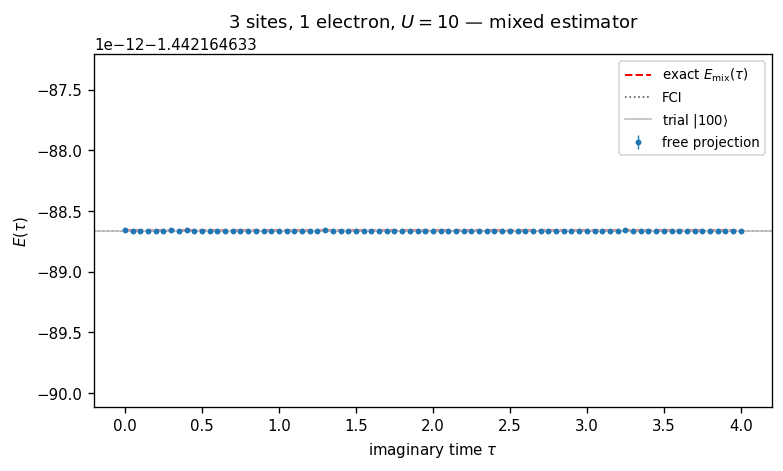

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(tau_grid, e_exact, "r--", lw=1.2, label=r"exact $E_{\rm mix}(\tau)$")
ax.axhline(e_fci, color="0.35", lw=1.0, ls=":", label="FCI")
ax.axhline(v_T @ h1 @ v_T, color="0.75", lw=1.0, label=r"trial $|100\rangle$")
ax.errorbar(fp.tau, fp.energy, fp.error, fmt="o", ms=2.5, lw=0.8,
            color="C0", label="free projection")

ax.set_xlabel(r"imaginary time $\tau$")
ax.set_ylabel(r"$E(\tau)$")
ax.set_title(r"3 sites, 1 electron, $U=%g$ — mixed estimator" % U)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

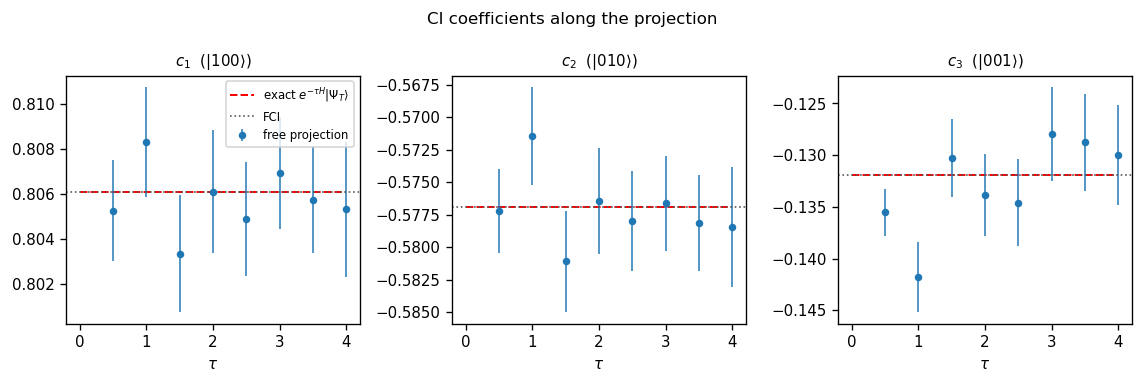

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2), sharex=True)
labels = [r"$c_1$  ($|100\rangle$)", r"$c_2$  ($|010\rangle$)", r"$c_3$  ($|001\rangle$)"]
fp_c    = np.array([fp_wfn[t]["c"] for t in fp_taus])
fp_cerr = np.array([fp_wfn[t]["c_err"] for t in fp_taus])

for k, ax in enumerate(axes):
    ax.plot(tau_grid, c_exact[:, k], "r--", lw=1.2,
            label=r"exact $e^{-\tau H}|\Psi_T\rangle$")
    ax.errorbar(fp_taus, fp_c[:, k], fp_cerr[:, k], fmt="o", ms=3.5, lw=0.9,
                color="C0", label="free projection")
    ax.axhline(c_fci[k], color="0.35", lw=1.0, ls=":", label="FCI")
    ax.set_xlabel(r"$\tau$"); ax.set_title(labels[k], fontsize=9)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("CI coefficients along the projection", fontsize=10)
fig.tight_layout(); plt.show()

In [11]:
def cloud(snaps, n_max=40000, seed=0):
    """
    Per-walker angles and signed contribution weight of a set of snapshots.

    The plotted point is the direction of the walker's *contribution*
    coef_w |phi_w> (coef_w = W_w for free projection, W_w/<Psi_T|phi_w> for the
    constrained path), so a walker that enters |Psi> with a negative sign shows up on
    the opposite side of the sphere rather than being silently folded back.
    """
    ang, wt = [], []
    for sn in snaps:
        c = hubbard.ci_vectors(sn)                              # (n_walkers, 3)
        coef = sn.weights / sn.overlaps if sn.importance else sn.weights
        d = coef[:, None] * c
        n = np.linalg.norm(d, axis=1)
        keep = (n > 0) & np.isfinite(n)
        ang.append(hubbard.angles_of(d[keep] / n[keep, None]))
        wt.append(n[keep])
    ang, wt = np.concatenate(ang), np.concatenate(wt)
    # if ang.shape[0] > n_max:
    #     idx = np.random.default_rng(seed).choice(ang.shape[0], n_max, replace=False)
    #     ang, wt = ang[idx], wt[idx]
    return ang[:, 1], ang[:, 0], wt / wt.max()                  # phi, theta, weight


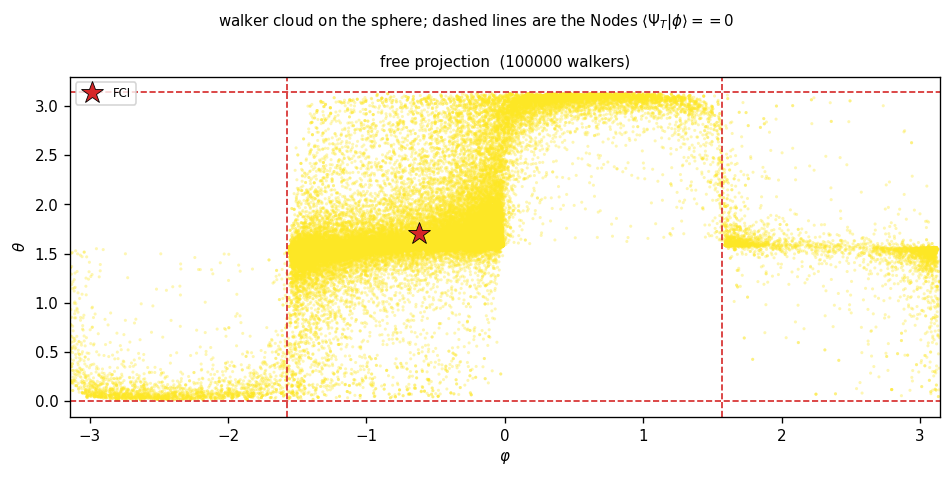

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4), sharex=True, sharey=True)
for ax, (name, snaps) in zip([axes], [("free projection", fp.snaps_at(fp_taus[-1]))]):
    ph_w, th_w, w = cloud(snaps)
    ax.scatter(ph_w, th_w, s=3.0 * w + 0.4, c=w, cmap="viridis",
               alpha=0.35, lw=0, vmin=0, vmax=1)
    for x in (-np.pi / 2, np.pi / 2):
        ax.axvline(x, color="C3", lw=1.0, ls="--")
    for y in (0, np.pi):
        ax.axhline(y, color="C3", lw=1.0, ls="--")
    ax.plot(ph_fci, th_fci, "*", ms=14, color="C3", mec="k", mew=0.5, label="FCI")
    # ax.plot(0.0, np.pi / 2, "s", ms=7, color="w", mec="k", mew=0.9, label=r"trial $|100\rangle$")
    ax.set_xlabel(r"$\varphi$"); ax.set_title("%s  (%d walkers)" % (name, ph_w.size), fontsize=9)
    ax.set_xlim(-np.pi, np.pi); #ax.set_ylim(0, np.pi)
axes.set_ylabel(r"$\theta$")
axes.legend(fontsize=7, loc="upper left")
fig.suptitle(r"walker cloud on the sphere; dashed lines are the Nodes "
             r"$\langle\Psi_T|\phi\rangle==0$", fontsize=9)
fig.tight_layout(); plt.show()

## 5b.  The nodes of the trial, and where the walkers sit

$\langle\Psi_T|\phi\rangle = 0$ is a **great circle** on the walker sphere — the equator
belonging to the trial, tilted so that $|\Psi_T\rangle$ is its pole.  In the notebook's
parametrisation, with the trial at $(\theta_t,\varphi_t)$,

$$
\langle\Psi_T|\phi\rangle
 = \underbrace{\sin\theta_t\cos(\varphi-\varphi_t)}_{a}\,\sin\theta
 + \underbrace{\cos\theta_t}_{b}\,\cos\theta ,
$$

so $a\sin\theta_n + b\cos\theta_n = 0$, i.e.

$$
\boxed{\;\cot\theta_n(\varphi) \;=\; -\tan\theta_t\,\cos(\varphi-\varphi_t)\;}
\qquad \theta_n\in(0,\pi).
$$

One $\theta$ for every $\varphi$: the node is a single-valued curve across the whole
$\varphi$ range, so it does have *both* angles, and it is not a set of straight lines.
Two checks of the formula: at $\varphi=\varphi_t$ it gives $\theta_n=\theta_t+\pi/2 \bmod \pi$
(a quarter turn from the trial along its own meridian), and at $\varphi=\varphi_t\pm\pi/2$ it
gives $\theta_n=\pi/2$ (the node crosses the true equator there).  Its excursion in $\theta$
is $[\arccos\sin\theta_t,\ \pi-\arccos\sin\theta_t]$.

The degenerate case is a trial sitting on the equator, $\cos\theta_t=0$: then $b=0$, the
formula has no solution for generic $\varphi$, and the node collapses to the two meridians
$\varphi=\varphi_t\pm\pi/2$ plus the poles.  That is exactly the old $|100\rangle$ trial, and
it is why the hard-coded vertical/horizontal lines in the scratch plot above looked the way
they did.  With the exact trial they are simply wrong, and the curve below replaces them.

A determinant is a ray, so $|\phi\rangle$ and $-|\phi\rangle$ are the same walker: the whole
picture is symmetric under the antipodal map $(\theta,\varphi)\to(\pi-\theta,\varphi\pm\pi)$,
the trial appears twice, and the node — being a great circle — is mapped onto itself.

In [13]:
th_t, ph_t = hubbard.angles_of(v_T)

def trial_nodes(phi, theta_t=None, phi_t=None):
    """
    theta_n(phi) on the nodal great circle <Psi_T|phi> = 0.

    Solves a sin(theta) + b cos(theta) = 0 with a = sin(tt) cos(phi - pt) and
    b = cos(tt), i.e. cot(theta_n) = -tan(tt) cos(phi - pt), taking the root with
    sin(theta_n) >= 0 so that theta_n lands in (0, pi).  Raises if the trial is on
    the equator, where the node is not a function of phi.
    """
    theta_t = th_t if theta_t is None else theta_t
    phi_t   = ph_t if phi_t   is None else phi_t
    a = np.sin(theta_t) * np.cos(np.asarray(phi, dtype=float) - phi_t)
    b = np.cos(theta_t)
    if abs(b) < 1e-13:
        raise ValueError("trial on the equator: the node is phi = phi_t +/- pi/2, "
                         "not a single-valued function of phi")
    return np.arctan2(abs(b), -a * np.sign(b))

phi_n = np.linspace(-np.pi, np.pi, 1441)
th_n  = trial_nodes(phi_n)

print("trial   c = (%+.6f, %+.6f, %+.6f)" % tuple(v_T))
print("        theta_t = %+.8f   phi_t = %+.8f" % (th_t, ph_t))
print("\nnode    cot(theta_n) = -tan(theta_t) cos(phi - phi_t)")
print("  max |<Psi_T|node>|                = %.2e" % np.abs(from_angles(th_n, phi_n) @ v_T).max())
print("  theta_n range                     = [%.8f, %.8f]" % (th_n.min(), th_n.max()))
print("  predicted [arccos sin tt, pi - .] = [%.8f, %.8f]"
      % (np.arccos(abs(np.sin(th_t))), np.pi - np.arccos(abs(np.sin(th_t)))))
print("  theta_n(phi_t)        = %.8f   (theta_t + pi/2 mod pi = %.8f)"
      % (trial_nodes(ph_t), (th_t + np.pi / 2) % np.pi))
print("  theta_n(phi_t + pi/2) = %.8f   (pi/2 = %.8f)"
      % (trial_nodes(ph_t + np.pi / 2), np.pi / 2))

# Independent check: the same circle built from an orthonormal basis of the plane
# perpendicular to Psi_T, with no reference to the angle parametrisation at all.
e1 = np.cross(v_T, [0.0, 0.0, 1.0]); e1 /= np.linalg.norm(e1)
e2 = np.cross(v_T, e1)
s  = np.linspace(0.0, 2 * np.pi, 1441)
gc = np.cos(s)[:, None] * e1 + np.sin(s)[:, None] * e2
ang_gc = hubbard.angles_of(gc)
print("\n  max |<Psi_T|great circle>|        = %.2e" % np.abs(gc @ v_T).max())
print("  max |theta_gc - theta_n(phi_gc)|  = %.2e"
      % np.abs(ang_gc[:, 0] - trial_nodes(ang_gc[:, 1])).max())

trial   c = (+0.806081, -0.576922, -0.131889)
        theta_t = +1.70307094   phi_t = -0.62119317

node    cot(theta_n) = -tan(theta_t) cos(phi - phi_t)
  max |<Psi_T|node>|                = 2.50e-16
  theta_n range                     = [0.13227478, 3.00931787]
  predicted [arccos sin tt, pi - .] = [0.13227461, 3.00931804]
  theta_n(phi_t)        = 0.13227461   (theta_t + pi/2 mod pi = 0.13227461)
  theta_n(phi_t + pi/2) = 1.57079633   (pi/2 = 1.57079633)

  max |<Psi_T|great circle>|        = 1.67e-16
  max |theta_gc - theta_n(phi_gc)|  = 3.11e-15


### The walker population, and its weight either side of the node

Free projection carries no importance sampling, so the ensemble *is* the wavefunction,
$|\Psi\rangle=\sum_w W_w|\phi_w\rangle$ with $W_w>0$; the sign lives in the walker's own
orientation.  Each walker is therefore plotted at the direction of its signed contribution
$W_w|\phi_w\rangle$, and $\langle\Psi_T|\phi_w\rangle$ says which side of the node it fell on.
The weight sitting on the wrong side is the free-projection sign problem, measured directly.

In [14]:
TAU_PLOT = fp_taus[-1]

def walker_cloud(snaps):
    """
    (phi, theta, weight, overlap) for every walker in a set of snapshots.

    The direction returned is that of the walker's signed contribution
    coef_w |phi_w>  (coef_w = W_w for free projection, W_w / <Psi_T|phi_w> when the
    snapshot is importance sampled), so a walker entering |Psi> with a negative sign
    shows up on the far side of the sphere rather than being folded back.  `overlap`
    is <Psi_T|phi_w> evaluated on that direction: its sign is the side of the node.
    """
    ang, wt = [], []
    for sn in snaps:
        c    = hubbard.ci_vectors(sn)                       # (n_walkers, 3)
        coef = sn.weights / sn.overlaps if sn.importance else sn.weights
        d    = coef[:, None] * c
        n    = np.linalg.norm(d, axis=1)
        keep = (n > 0) & np.isfinite(n)
        ang.append(hubbard.angles_of(d[keep] / n[keep, None]))
        wt.append(n[keep])
    ang, wt = np.concatenate(ang), np.concatenate(wt)
    th, ph  = ang[:, 0], ang[:, 1]
    return ph, th, wt, from_angles(th, ph) @ v_T

ph_w, th_w, w_w, ovl_w = walker_cloud(fp.snaps_at(TAU_PLOT))
w_w = w_w / w_w.sum()                                   # a probability weight
pos = ovl_w > 0

print("tau = %.2f : %d walkers from %d trajectories" % (TAU_PLOT, ph_w.size, fp.n_runs))
print("  weight with <Psi_T|phi> > 0     : %6.2f %%" % (100 * w_w[pos].sum()))
print("  weight with <Psi_T|phi> < 0     : %6.2f %%" % (100 * w_w[~pos].sum()))
print("  sum_w W |<Psi_T|phi_w>|         : %+.6f" % np.sum(w_w * np.abs(ovl_w)))
print("  sum_w W  <Psi_T|phi_w>          : %+.6f   <- the signal that survives"
      % np.sum(w_w * ovl_w))
print("  ratio (average sign)            : %+.6f"
      % (np.sum(w_w * ovl_w) / np.sum(w_w * np.abs(ovl_w))))

tau = 4.00 : 100000 walkers from 100 trajectories
  weight with <Psi_T|phi> > 0     :  94.04 %
  weight with <Psi_T|phi> < 0     :   5.96 %
  sum_w W |<Psi_T|phi_w>|         : +0.752991
  sum_w W  <Psi_T|phi_w>          : +0.689492   <- the signal that survives
  ratio (average sign)            : +0.915671


normalisation checks:  int rho(phi) dphi = 1.000000   int rho(theta) dtheta = 1.000000


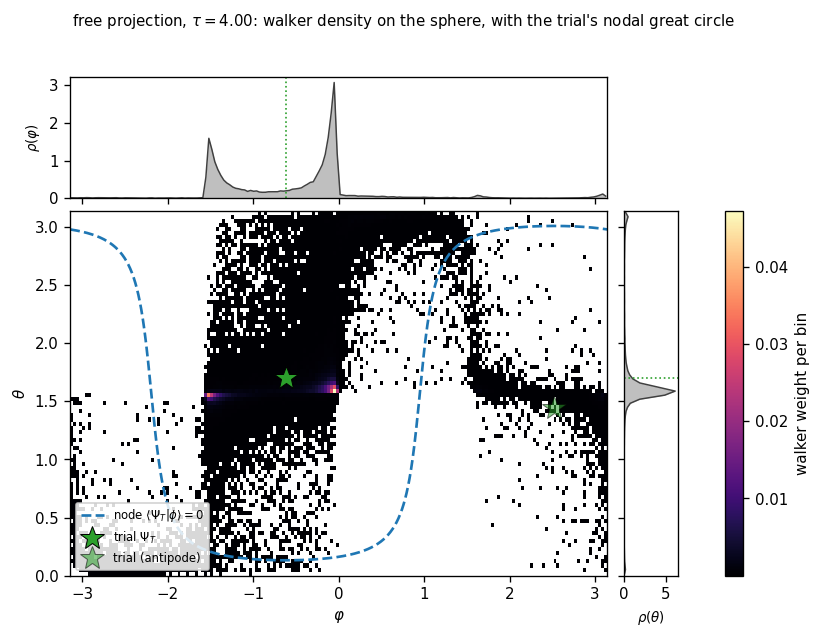

In [15]:
# One weighted 2-D histogram of the population on the sphere.  The two marginals are
# literally its row and column sums, i.e. the density integrated over the other angle.
NB_P, NB_T = 180, 90
ep = np.linspace(-np.pi, np.pi, NB_P + 1)
et = np.linspace(0.0,    np.pi, NB_T + 1)
dp, dt_ = ep[1] - ep[0], et[1] - et[0]
ctr_p, ctr_t = 0.5 * (ep[1:] + ep[:-1]), 0.5 * (et[1:] + et[:-1])

H,  _, _ = np.histogram2d(ph_w,       th_w,       bins=[ep, et], weights=w_w)
Hp, _, _ = np.histogram2d(ph_w[pos],  th_w[pos],  bins=[ep, et], weights=w_w[pos])
Hm, _, _ = np.histogram2d(ph_w[~pos], th_w[~pos], bins=[ep, et], weights=w_w[~pos])

rho_phi,   rho_theta   = H.sum(1) / dp,  H.sum(0) / dt_
rho_phi_p, rho_theta_p = Hp.sum(1) / dp, Hp.sum(0) / dt_
rho_phi_m, rho_theta_m = Hm.sum(1) / dp, Hm.sum(0) / dt_
print("normalisation checks:  int rho(phi) dphi = %.6f   int rho(theta) dtheta = %.6f"
      % (rho_phi.sum() * dp, rho_theta.sum() * dt_))

fig = plt.figure(figsize=(7.4, 5.4))
gs  = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 3),
                       wspace=0.05, hspace=0.05)
ax  = fig.add_subplot(gs[1, 0])
axp = fig.add_subplot(gs[0, 0], sharex=ax)
axt = fig.add_subplot(gs[1, 1], sharey=ax)

pcm = ax.pcolormesh(ep, et, np.ma.masked_equal(H, 0).T, cmap="magma", shading="auto")
ax.plot(phi_n, th_n, "--", color="C0", lw=1.6, label=r"node $\langle\Psi_T|\phi\rangle=0$")
ax.plot(ph_t, th_t, "*", ms=15, color="C2", mec="k", mew=0.6, label=r"trial $\Psi_T$")
ax.plot(ph_t - np.sign(ph_t) * np.pi, np.pi - th_t, "*", ms=15, color="C2",
        mec="k", mew=0.6, alpha=0.55, label=r"trial (antipode)")
ax.set_xlabel(r"$\varphi$"); ax.set_ylabel(r"$\theta$")
ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, np.pi)
ax.legend(fontsize=7, loc="lower left", framealpha=0.85)

axp.fill_between(ctr_p, rho_phi, color="0.75", lw=0)
axp.plot(ctr_p, rho_phi, color="0.25", lw=0.9)
axp.axvline(ph_t, color="C2", lw=1.0, ls=":")
axp.set_ylabel(r"$\rho(\varphi)$", fontsize=8); axp.tick_params(labelbottom=False)
axp.set_ylim(bottom=0)

axt.fill_betweenx(ctr_t, rho_theta, color="0.75", lw=0)
axt.plot(rho_theta, ctr_t, color="0.25", lw=0.9)
axt.axhline(th_t, color="C2", lw=1.0, ls=":")
axt.set_xlabel(r"$\rho(\theta)$", fontsize=8); axt.tick_params(labelleft=False)
axt.set_xlim(left=0)

fig.colorbar(pcm, ax=[axt], location="right", fraction=0.25, pad=0.35,
             label="walker weight per bin")
fig.suptitle(r"free projection, $\tau=%.2f$: walker density on the sphere, "
             r"with the trial's nodal great circle" % TAU_PLOT, fontsize=9)
plt.show()

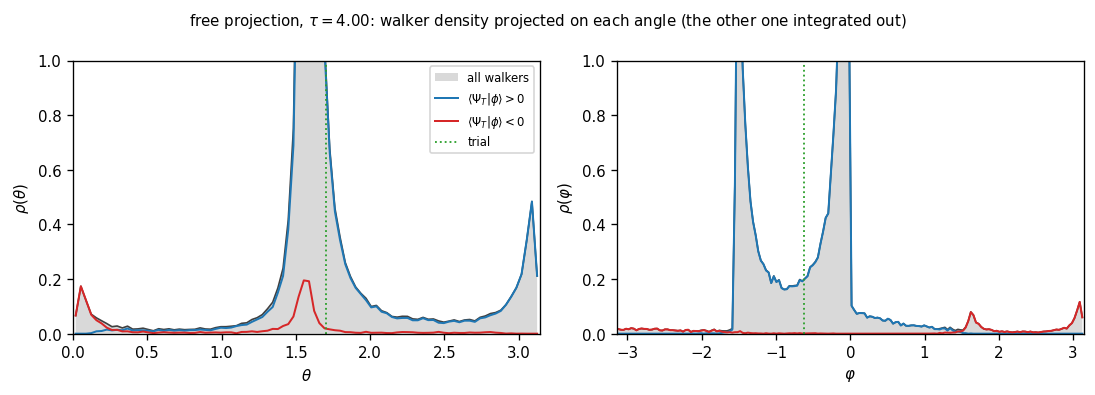

In [16]:
# The same two marginals on their own, split by which side of the node the weight is on.
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))

for ax, ctr, tot, p, m, lab, mark in (
        (axes[0], ctr_t, rho_theta, rho_theta_p, rho_theta_m, r"\theta", th_t),
        (axes[1], ctr_p, rho_phi,   rho_phi_p,   rho_phi_m,   r"\varphi", ph_t)):
    ax.fill_between(ctr, tot, color="0.85", lw=0, label="all walkers")
    ax.plot(ctr, tot, color="0.25", lw=1.0)
    ax.plot(ctr, p, color="C0", lw=1.2, label=r"$\langle\Psi_T|\phi\rangle>0$")
    ax.plot(ctr, m, color="C3", lw=1.2, label=r"$\langle\Psi_T|\phi\rangle<0$")
    ax.axvline(mark, color="C2", lw=1.1, ls=":", label="trial")
    ax.set_xlabel("$%s$" % lab); ax.set_ylabel(r"$\rho(%s)$" % lab)
    # ax.set_ylim(bottom=0)
    ax.set_ylim(0, 1)
axes[0].set_xlim(0, np.pi); axes[1].set_xlim(-np.pi, np.pi)
axes[0].legend(fontsize=7)
fig.suptitle(r"free projection, $\tau=%.2f$: walker density projected on each angle "
             r"(the other one integrated out)" % TAU_PLOT, fontsize=9)
fig.tight_layout(); plt.show()

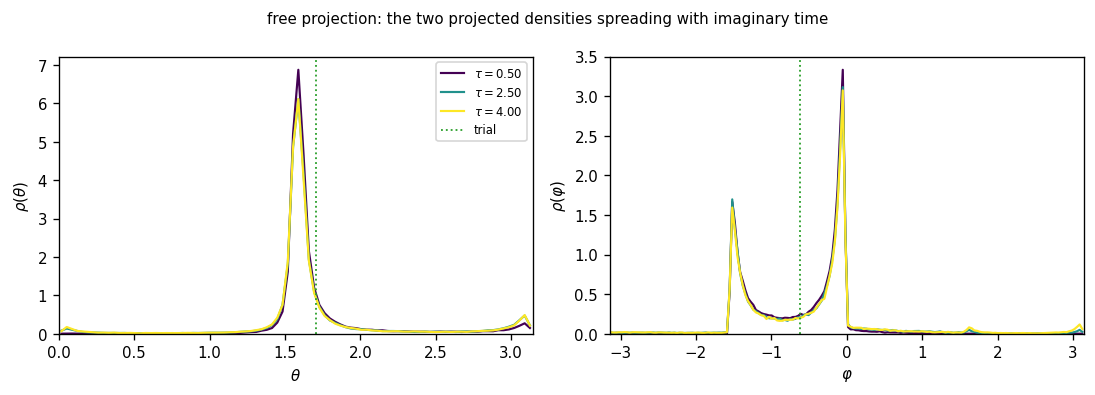

In [17]:
# How the two projections build up along the projection time.
taus_show = [fp_taus[0], fp_taus[len(fp_taus) // 2], fp_taus[-1]]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))

for k, tau in enumerate(taus_show):
    p_, t_, wt_, _ = walker_cloud(fp.snaps_at(tau))
    wt_ = wt_ / wt_.sum()
    ht, _ = np.histogram(t_, bins=et, weights=wt_)
    hp, _ = np.histogram(p_, bins=ep, weights=wt_)
    col = plt.cm.viridis(k / max(1, len(taus_show) - 1))
    axes[0].plot(ctr_t, ht / dt_, color=col, lw=1.3, label=r"$\tau=%.2f$" % tau)
    axes[1].plot(ctr_p, hp / dp,  color=col, lw=1.3, label=r"$\tau=%.2f$" % tau)

for ax, lab, mark in ((axes[0], r"\theta", th_t), (axes[1], r"\varphi", ph_t)):
    ax.axvline(mark, color="C2", lw=1.1, ls=":", label="trial")
    ax.set_xlabel("$%s$" % lab); ax.set_ylabel(r"$\rho(%s)$" % lab)
    ax.set_ylim(bottom=0)
axes[0].set_xlim(0, np.pi); axes[1].set_xlim(-np.pi, np.pi)
axes[0].legend(fontsize=7)
fig.suptitle("free projection: the two projected densities spreading with imaginary time",
             fontsize=9)
fig.tight_layout(); plt.show()

## 6.  Constrained-path AFQMC

Importance sampling with the same trial, and walkers killed the moment
$\langle\Psi_T|\phi_w\rangle$ would change sign.  The mixed distribution is sampled, so
reconstructing $|\Psi\rangle$ divides the trial overlap back out,
$|\Psi\rangle=\sum_w (W_w/\langle\Psi_T|\phi_w\rangle)|\phi_w\rangle$ — `hubbard.reconstruct`
picks that up from the snapshot automatically.

**One walk, not many.**  Unlike free projection, constrained path has a steady state:
importance sampling keeps the weights alive, so the walk is equilibrated once and then
sampled block after block, exactly as `afqmc/scripts/run_afqmc.py` does.  Restarting it
$N$ times would pay the equilibration cost $N$ times over and buy nothing.  The price is
that consecutive blocks are correlated, so the energy error bar comes from a blocking
analysis of the single series (`sampling.blocking`, via `QMCResult.plateau`), and the
snapshots are labelled by which contiguous **bin** of the walk they came from so that
`hubbard.wavefunction` jackknifes over bins rather than over neighbouring, correlated
snapshots.

The constraint here has a completely explicit geometry:
$\langle\Psi_T|\phi\rangle=\sin\theta\cos\varphi$ for the $|100\rangle$ trial, so such a
walker can never leave the wedge $|\varphi|<\pi/2$, whereas free projection roams the whole
sphere.

In [18]:
cp = hubbard.run_constrained(
        qmc, method="cp", dt=0.001, n_walkers=2000, n_prop_steps=50,
        n_blocks=400, eql_time=10.0, seed=0, n_exp_terms=10,
        n_bins=10, snap_every=4, verbose=1)


Constrained path | 2000 walkers | equilibrating 200 blocks to tau = 10.00
  eql   40/200  tau =   2.00  E(block) =   -1.44216     3.4 s
  eql   80/200  tau =   4.00  E(block) =   -1.44216     3.9 s
  eql  120/200  tau =   6.00  E(block) =   -1.44216     4.3 s
  eql  160/200  tau =   8.00  E(block) =   -1.44216     4.7 s
  eql  200/200  tau =  10.00  E(block) =   -1.44216     5.1 s

Constrained path | sampling 400 blocks from the same walk
  block     tau    E(block)         <E>        err  walltime
      4   10.20    -1.44216    -1.44216         --       5.1
      8   10.40    -1.44216    -1.44216         --       5.2
     12   10.60    -1.44216    -1.44216         --       5.2
     16   10.80    -1.44216    -1.44216         --       5.3
     20   11.00    -1.44216    -1.44216         --       5.3
     24   11.20    -1.44216    -1.44216    0.00000       5.4
     28   11.40    -1.44216    -1.44216    0.00000       5.4
     32   11.60    -1.44216    -1.44216    0.00000       5.4
     36

In [19]:
e_cp, e_cp_err = cp.plateau()
r_cp = hubbard.wavefunction(cp.snaps, qmc.ci_hamiltonian, v_T)

print("constrained path: %d blocks sampled from one walk after tau_eq = %.1f"
      % (cp.block_energies.shape[1], cp.tau_eq))
print("  c     = (%+.6f, %+.6f, %+.6f)" % tuple(r_cp["c"]))
print("  +/-   = ( %.6f,  %.6f,  %.6f)   (jackknife over %d bins of the walk)"
      % (*r_cp["c_err"], r_cp["n_groups"]))
print("  theta = %+.6f +/- %.6f    (FCI %+.6f)" % (r_cp["theta"], r_cp["theta_err"], th_fci))
print("  phi   = %+.6f +/- %.6f    (FCI %+.6f)" % (r_cp["phi"], r_cp["phi_err"], ph_fci))
print("  E_var = %+.6f    E_mix = %+.5f +/- %.5f    (FCI %+.6f)"
      % (r_cp["e_var"], e_cp, e_cp_err, e_fci))

constrained path: 400 blocks sampled from one walk after tau_eq = 10.0
  c     = (+0.804092, -0.576178, -0.146476)
  +/-   = ( 0.001776,  0.002937,  0.004413)   (jackknife over 10 bins of the walk)
  theta = +1.717801 +/- 0.004461    (FCI +1.703071)
  phi   = -0.621753 +/- 0.003406    (FCI -0.621193)
  E_var = -1.441829    E_mix = -1.44216 +/- 0.00000    (FCI -1.442165)


## 7.  The three answers side by side

In [20]:
rows = [("FCI",               c_fci,      None,             e_fci,        None),
        ("free projection",   r_fp["c"],  r_fp["c_err"],    r_fp["e_var"], fp.energy[-1]),
        ("constrained path",  r_cp["c"],  r_cp["c_err"],    r_cp["e_var"], e_cp)]

print("CI coefficients in the basis {|100>, |010>, |001>}")
print("-" * 92)
print("%-18s %11s %11s %11s %10s %10s %11s" % ("", "c1", "c2", "c3", "theta", "phi", "E_var"))
print("-" * 92)
for name, c, cerr, evar, emix in rows:
    th, ph = hubbard.angles_of(c)
    print("%-18s %+11.6f %+11.6f %+11.6f %10.6f %10.6f %+11.6f"
          % (name, c[0], c[1], c[2], th, ph, evar))
    if cerr is not None:
        print("%-18s %11s %11s %11s"
              % ("  +/-", "%.6f" % cerr[0], "%.6f" % cerr[1], "%.6f" % cerr[2]))
print("-" * 92)
print("deviation from FCI, |c - c_FCI|:")
for name, c, cerr, evar, emix in rows[1:]:
    print("  %-18s %.2e   (energy error %+.2e)" % (name, np.linalg.norm(c - c_fci), evar - e_fci))

CI coefficients in the basis {|100>, |010>, |001>}
--------------------------------------------------------------------------------------------
                            c1          c2          c3      theta        phi       E_var
--------------------------------------------------------------------------------------------
FCI                  +0.806081   -0.576922   -0.131889   1.703071  -0.621193   -1.442165
free projection      +0.805306   -0.578431   -0.129995   1.701160  -0.622886   -1.442158
  +/-                 0.003002    0.004622    0.004846
constrained path     +0.804092   -0.576178   -0.146476   1.717801  -0.621753   -1.441829
  +/-                 0.001776    0.002937    0.004413
--------------------------------------------------------------------------------------------
deviation from FCI, |c - c_FCI|:
  free projection    2.54e-03   (energy error +7.09e-06)
  constrained path   1.47e-02   (energy error +3.36e-04)


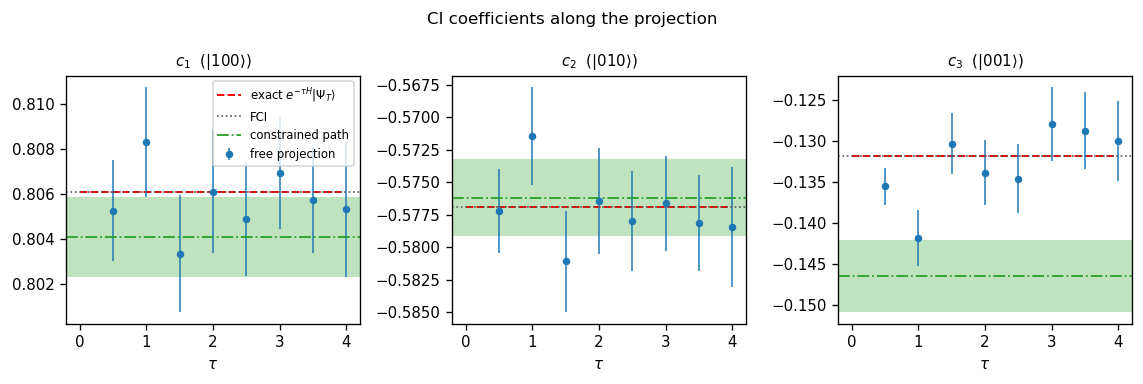

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2), sharex=True)
labels = [r"$c_1$  ($|100\rangle$)", r"$c_2$  ($|010\rangle$)", r"$c_3$  ($|001\rangle$)"]
fp_c    = np.array([fp_wfn[t]["c"] for t in fp_taus])
fp_cerr = np.array([fp_wfn[t]["c_err"] for t in fp_taus])

for k, ax in enumerate(axes):
    ax.plot(tau_grid, c_exact[:, k], "r--", lw=1.2,
            label=r"exact $e^{-\tau H}|\Psi_T\rangle$")
    ax.errorbar(fp_taus, fp_c[:, k], fp_cerr[:, k], fmt="o", ms=3.5, lw=0.9,
                color="C0", label="free projection")
    ax.axhline(c_fci[k], color="0.35", lw=1.0, ls=":", label="FCI")
    ax.axhspan(r_cp["c"][k] - r_cp["c_err"][k], r_cp["c"][k] + r_cp["c_err"][k],
               color="C2", alpha=0.30, lw=0)
    ax.axhline(r_cp["c"][k], color="C2", lw=1.1, ls="-.", label="constrained path")
    ax.set_xlabel(r"$\tau$"); ax.set_title(labels[k], fontsize=9)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("CI coefficients along the projection", fontsize=10)
fig.tight_layout(); plt.show()

In [22]:
ph_w, th_w, w_w, ovl_w = walker_cloud(cp.snaps)
w_w = w_w / w_w.sum()                                   # a probability weight
pos = ovl_w > 0

print(" %d walkers from %d snapshots of one walk" % (ph_w.size, len(cp.snaps)))
print("  weight with <Psi_T|phi> > 0     : %6.2f %%" % (100 * w_w[pos].sum()))
print("  weight with <Psi_T|phi> < 0     : %6.2f %%" % (100 * w_w[~pos].sum()))
print("  sum_w W |<Psi_T|phi_w>|         : %+.6f" % np.sum(w_w * np.abs(ovl_w)))
print("  sum_w W  <Psi_T|phi_w>          : %+.6f   <- the signal that survives"
      % np.sum(w_w * ovl_w))
print("  ratio (average sign)            : %+.6f"
      % (np.sum(w_w * ovl_w) / np.sum(w_w * np.abs(ovl_w))))

 200000 walkers from 100 snapshots of one walk
  weight with <Psi_T|phi> > 0     : 100.00 %
  weight with <Psi_T|phi> < 0     :   0.00 %
  sum_w W |<Psi_T|phi_w>|         : +0.775386
  sum_w W  <Psi_T|phi_w>          : +0.775386   <- the signal that survives
  ratio (average sign)            : +1.000000


normalisation checks:  int rho(phi) dphi = 1.000000   int rho(theta) dtheta = 1.000000


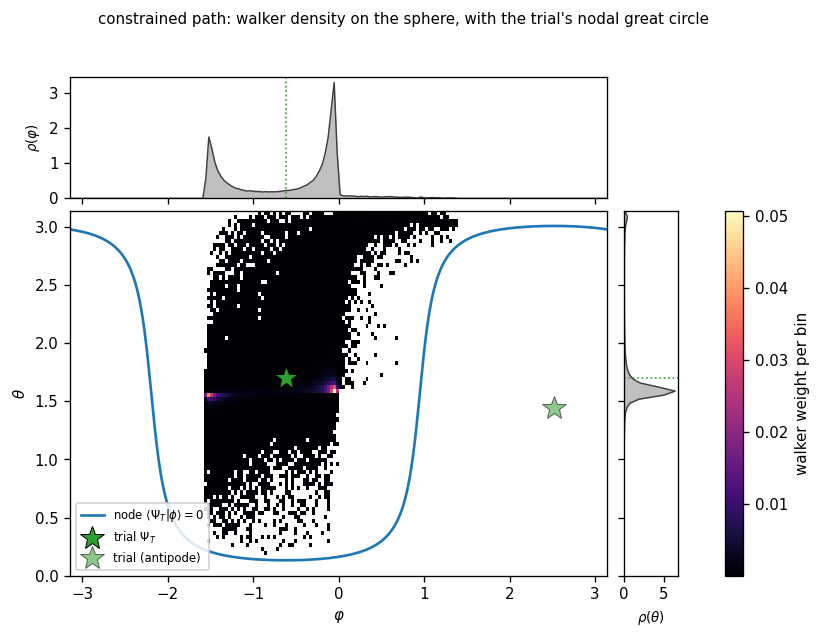

In [23]:
# One weighted 2-D histogram of the population on the sphere.  The two marginals are
# literally its row and column sums, i.e. the density integrated over the other angle.
NB_P, NB_T = 180, 90
ep = np.linspace(-np.pi, np.pi, NB_P + 1)
et = np.linspace(0.0,    np.pi, NB_T + 1)
dp, dt_ = ep[1] - ep[0], et[1] - et[0]
ctr_p, ctr_t = 0.5 * (ep[1:] + ep[:-1]), 0.5 * (et[1:] + et[:-1])

H,  _, _ = np.histogram2d(ph_w,       th_w,       bins=[ep, et], weights=w_w)
Hp, _, _ = np.histogram2d(ph_w[pos],  th_w[pos],  bins=[ep, et], weights=w_w[pos])
Hm, _, _ = np.histogram2d(ph_w[~pos], th_w[~pos], bins=[ep, et], weights=w_w[~pos])

rho_phi,   rho_theta   = H.sum(1) / dp,  H.sum(0) / dt_
rho_phi_p, rho_theta_p = Hp.sum(1) / dp, Hp.sum(0) / dt_
rho_phi_m, rho_theta_m = Hm.sum(1) / dp, Hm.sum(0) / dt_
print("normalisation checks:  int rho(phi) dphi = %.6f   int rho(theta) dtheta = %.6f"
      % (rho_phi.sum() * dp, rho_theta.sum() * dt_))

fig = plt.figure(figsize=(7.4, 5.4))
gs  = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 3),
                       wspace=0.05, hspace=0.05)
ax  = fig.add_subplot(gs[1, 0])
axp = fig.add_subplot(gs[0, 0], sharex=ax)
axt = fig.add_subplot(gs[1, 1], sharey=ax)

pcm = ax.pcolormesh(ep, et, np.ma.masked_equal(H, 0).T, cmap="magma", shading="auto")
ax.plot(phi_n, th_n, "-", color="C0", lw=1.6, label=r"node $\langle\Psi_T|\phi\rangle=0$")
ax.plot(ph_t, th_t, "*", ms=15, color="C2", mec="k", mew=0.6, label=r"trial $\Psi_T$")
ax.plot(ph_t - np.sign(ph_t) * np.pi, np.pi - th_t, "*", ms=15, color="C2",
        mec="k", mew=0.6, alpha=0.55, label=r"trial (antipode)")
ax.set_xlabel(r"$\varphi$"); ax.set_ylabel(r"$\theta$")
ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, np.pi)
ax.legend(fontsize=7, loc="lower left", framealpha=0.85)

axp.fill_between(ctr_p, rho_phi, color="0.75", lw=0)
axp.plot(ctr_p, rho_phi, color="0.25", lw=0.9)
axp.axvline(ph_t, color="C2", lw=1.0, ls=":")
axp.set_ylabel(r"$\rho(\varphi)$", fontsize=8); axp.tick_params(labelbottom=False)
axp.set_ylim(bottom=0)

axt.fill_betweenx(ctr_t, rho_theta, color="0.75", lw=0)
axt.plot(rho_theta, ctr_t, color="0.25", lw=0.9)
axt.axhline(th_t, color="C2", lw=1.0, ls=":")
axt.set_xlabel(r"$\rho(\theta)$", fontsize=8); axt.tick_params(labelleft=False)
axt.set_xlim(left=0)

fig.colorbar(pcm, ax=[axt], location="right", fraction=0.25, pad=0.35,
             label="walker weight per bin")
fig.suptitle(r"constrained path: walker density on the sphere, "
             r"with the trial's nodal great circle", fontsize=9)
plt.show()

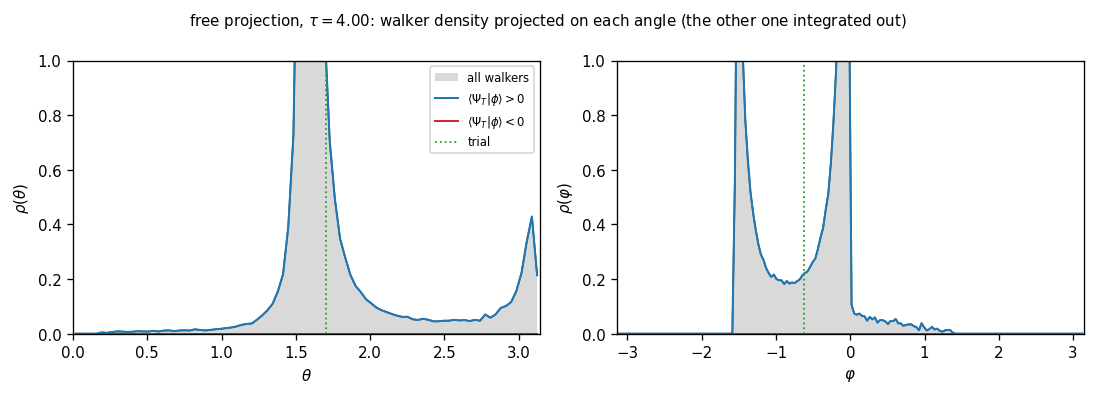

In [24]:
# The same two marginals on their own, split by which side of the node the weight is on.
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3))

for ax, ctr, tot, p, m, lab, mark in (
        (axes[0], ctr_t, rho_theta, rho_theta_p, rho_theta_m, r"\theta", th_t),
        (axes[1], ctr_p, rho_phi,   rho_phi_p,   rho_phi_m,   r"\varphi", ph_t)):
    ax.fill_between(ctr, tot, color="0.85", lw=0, label="all walkers")
    ax.plot(ctr, tot, color="0.25", lw=1.0)
    ax.plot(ctr, p, color="C0", lw=1.2, label=r"$\langle\Psi_T|\phi\rangle>0$")
    ax.plot(ctr, m, color="C3", lw=1.2, label=r"$\langle\Psi_T|\phi\rangle<0$")
    ax.axvline(mark, color="C2", lw=1.1, ls=":", label="trial")
    ax.set_xlabel("$%s$" % lab); ax.set_ylabel(r"$\rho(%s)$" % lab)
    # ax.set_ylim(bottom=0)
    ax.set_ylim(0, 1)
axes[0].set_xlim(0, np.pi); axes[1].set_xlim(-np.pi, np.pi)
axes[0].legend(fontsize=7)
fig.suptitle(r"free projection, $\tau=%.2f$: walker density projected on each angle "
             r"(the other one integrated out)" % TAU_PLOT, fontsize=9)
fig.tight_layout(); plt.show()

## 8.  Multiconfigurational constrained path

The constraint is imposed on a **group** of walkers rather than on each walker.  Walkers
are partitioned into fixed groups of `nwalker_per_group`; a group carries one weight and
one determinant sum $|\phi_g(n)\rangle=\sum_{i\in g}|\phi_i(n)\rangle$, the QMC state is

$$|\psi(n)\rangle=\sum_g \frac{W_g(n)}{\langle\Psi_T|\phi_g(n)\rangle}\,|\phi_g(n)\rangle ,$$

the weight is updated with — and constrained on — the *group* overlap ratio

$$W_g(n+1)=W_g(n)\cdot\max\Big(0,\ \mathrm{Re}\ \frac{\sum_{i\in g}\langle\Psi_T|\phi_i(n+1)\rangle}
{\sum_{i\in g}\langle\Psi_T|\phi_i(n)\rangle}\Big),$$

and the block energy is the group energy

$$E_g(n)=\frac{\sum_{i\in g}\langle\Psi_T|H|\phi_i\rangle}{\sum_{i\in g}\langle\Psi_T|\phi_i\rangle}
       =\frac{\sum_{i\in g}\langle\Psi_T|\phi_i\rangle\,E_{\rm loc}(\phi_i)}
              {\sum_{i\in g}\langle\Psi_T|\phi_i\rangle}.$$

Like plain constrained path this is **one open-ended walk**: equilibrate for
`eql_time`, discard, then keep sampling blocks from the same walk, with the error
bar from a blocking analysis of that single series and snapshots labelled by the
contiguous bin of the walk they came from.

### What had to be fixed in the draft

1. **Where the importance factor goes.**  The draft multiplied the per-walker prefactor
   $N_i=\exp(-\sqrt{\delta\tau}\,\bar x\!\cdot\!\langle v\rangle + \text{fb} + \delta\tau(E_{\rm sh}+h_0))$,
   shape `(n_walkers,)`, by the group overlap ratio, shape `(n_groups,)` — shapes that do
   not broadcast.  More than a shape bug: $N_i$ *differs between members of a group*, so it
   cannot multiply the group weight at all.  It is folded into the walker instead (spread
   over the occupied columns, exactly as `propagate_free` does with its phase) and reaches
   the weight through the group overlap ratio.  For a group of one the two are identical.
2. **`stochastic_reconfiguration_local`** called `prop_data["walkers"].reshape(...)`, but
   `walkers` is a *list* `[up, dn]` of `(n_walkers, norb, nocc)` arrays and has no
   `.reshape`.  Groups also have to be replicated **whole**, so the reshape is to
   `(n_groups, nwalker_per_group, norb, nocc)` and the SR indices select on axis 0.
3. **`get_group_norm`** was empty.  Filled in as
   $N_g=\sqrt{\sum_{i,j\in g}\langle\phi_i|\phi_j\rangle}$ — the double sum of `u_overlap`,
   done with one `einsum` + `det` per spin channel.
4. **`prop_nstep`'s renormalisation.**  `constant = norm / group_norm` mixed shapes
   `(2, n_walkers)` and `(n_groups,)`; the group norm has to be repeated over the members
   (`jnp.repeat`), and the factor has to be spread as a $1/N_e$ power so that it multiplies
   the *determinant* by the intended amount.  The stored overlaps must then be recomputed,
   or the next step's ratio is taken against a stale denominator.
5. **`block_sample`** called `prop.stochastic_reconfiguration_uhf_group` (a module-level
   function, not a method), never refreshed `prop_data["overlaps"]` after reconfiguring,
   and counted killed walkers from `prop_data["weights"]`, which this scheme never updates.
6. **`nwalker_per_group` was a bare class attribute**, so it was invisible to the dataclass
   `__hash__`; with `self` static in `jit`, two group sizes would have collided in the trace
   cache.  It is a field now, with `__hash__` redefined.
7. **NaN guards.**  A group whose summed overlap passes through zero gives a divergent group
   energy.  Zeroing its weight is not enough, because `sampling.weighted_average` forms
   `weights * samples` and `0 * inf = nan` poisons the whole block mean — the energy itself
   has to be replaced first.  Similarly the ratio needs `isfinite` (not just `isnan`), the
   population-control shift needs a guard against a fully dead population, and SR must not
   be handed an all-zero weight vector.  Without these, `nwalker_per_group` = 2 and 5
   returned `nan`.

In [25]:
# multiconfigurational constrained path -- imports it needs on top of the notebook's
from dataclasses import dataclass
from functools import partial
import time

import jax.numpy as jnp
from jax import jit, lax, random
from afqmc import linalg_utils, sampling, sr

@dataclass
class propagator_cp_mc(hubbard.propagator_uhf_gen):
    r"""
    Multiconfigurational constrained path.

    The walkers are partitioned into fixed groups of `nwalker_per_group`.  A group
    carries one weight and one determinant-sum

        |phi_g(n)> = sum_{i in g} |phi_i(n)> ,

    and the QMC state is  |psi(n)> = sum_g  W_g(n) / <T|phi_g(n)>  |phi_g(n)>.
    The weight is updated with the *group* overlap ratio and constrained on that,

        W_g(n+1) = W_g(n) * max(0, Re [ sum_{i in g} <T|phi_i(n+1)>
                                      / sum_{i in g} <T|phi_i(n)> ]),

    so an individual walker may cross the trial's node as long as the group it
    belongs to does not.  `nwalker_per_group = 1` reduces exactly to single-walker
    constrained path; taking one group reduces to free projection with the overall
    sign constrained.

    Note on where the importance factor goes
    ----------------------------------------
    In single-walker CP the per-walker prefactor
    N_i = exp(-sqrt(dt) x.<v> + fb - dt(E_shift + h0)) multiplies the *weight*.
    Here it cannot: it differs from walker to walker inside a group, and only the
    relative amplitudes of the members define |phi_g>.  N_i is therefore folded
    into the walker itself (spread over the occupied columns, as `propagate_free`
    does with its phase), and reaches the weight through the group overlap ratio.
    For a group of one the two are algebraically the same thing.
    """

    nwalker_per_group: int = 50

    def __hash__(self) -> int:
        # @dataclass regenerates __eq__ and clears __hash__; both must see
        # nwalker_per_group or jit will reuse a trace made for another group size.
        return hash(tuple(self.__dict__.values()))

    @property
    def n_groups(self) -> int:
        return self.n_walkers // self.nwalker_per_group

    def _spread(self, factors, n_tot):
        """factors^(1/n_tot), the per-column constant giving a determinant factor."""
        if n_tot == 1:
            return factors                       # keeps a real walker real
        mag = jnp.abs(factors)
        return mag ** (1.0 / n_tot) * (factors / mag) ** (1.0 / n_tot)

    def init_prop_data(self, trial, wave_data, ham_data, init_walkers=None):
        prop_data = super().init_prop_data(trial, wave_data, ham_data, init_walkers)
        prop_data["group_weights"] = jnp.ones(self.n_groups)
        prop_data["n_killed_groups"] = 0
        return prop_data

    @partial(jit, static_argnums=(0, 1))
    def propagate(self, trial, ham_data, prop_data, fields, wave_data):
        n_tot = trial.nelec[0] + trial.nelec[1]
        npg = self.nwalker_per_group

        force_bias = trial.calc_force_bias(prop_data["walkers"], ham_data, wave_data)
        field_shifts = -jnp.sqrt(self.dt) * (1.0j * force_bias - ham_data["mf_shifts"])
        shifted_fields = fields - field_shifts

        shift_term = jnp.sum(shifted_fields * ham_data["mf_shifts"], axis=1)
        fb_term = jnp.sum(fields * field_shifts - field_shifts * field_shifts / 2.0, axis=1)

        prop_data["walkers"] = self._apply_trotprop(
            ham_data, prop_data["walkers"], shifted_fields)

        # fold the per-walker importance factor into the walker
        n_i = jnp.exp(-jnp.sqrt(self.dt) * shift_term + fb_term
                      + self.dt * (prop_data["pop_control_ene_shift"] + ham_data["h0_prop"]))
        c = self._spread(n_i, n_tot)
        prop_data["walkers"] = self._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))

        overlaps_new = trial.calc_overlap(prop_data["walkers"], wave_data)

        # the group ratio, and the constraint on it
        num = jnp.sum(overlaps_new.reshape(-1, npg), axis=1)
        den = jnp.sum(prop_data["overlaps"].reshape(-1, npg), axis=1)
        ratio = jnp.real(num / den)
        ratio = jnp.where(jnp.isfinite(ratio), ratio, 0.0)      # den passed through 0
        ratio = jnp.where(ratio < 0.0, 0.0, ratio)              # kill node-crossing groups
        ratio = jnp.where(ratio > 100.0, 0.0, ratio)

        prop_data["group_weights"] = ratio * prop_data["group_weights"]
        prop_data["group_weights"] = jnp.where(prop_data["group_weights"] > 100.0, 0.0,
                                               prop_data["group_weights"])
        total = jnp.sum(prop_data["group_weights"])
        prop_data["pop_control_ene_shift"] = prop_data["e_estimate"] - 0.1 * jnp.where(
            total > 0.0, jnp.log(total / self.n_groups) / self.dt, 0.0)
        prop_data["overlaps"] = overlaps_new
        return prop_data

    @partial(jit, static_argnums=(0,))
    def get_group_norm(self, prop_data):
        r"""
        N_g = sqrt( sum_{i,j in g} <phi_i|phi_j> ) = || sum_{i in g} |phi_i> || .

        <phi_i|phi_j> = det(u_i^H u_j) det(d_i^H d_j) is `u_overlap` evaluated for
        every pair inside a group; the double sum is done with one einsum per spin.
        """
        npg = self.nwalker_per_group
        up, dn = prop_data["walkers"][0], prop_data["walkers"][1]
        ng = up.shape[0] // npg
        gu = up.reshape(ng, npg, up.shape[1], up.shape[2])
        gd = dn.reshape(ng, npg, dn.shape[1], dn.shape[2])
        s_up = jnp.linalg.det(jnp.einsum("gima,gjmb->gijab", gu.conj(), gu))
        s_dn = jnp.linalg.det(jnp.einsum("gima,gjmb->gijab", gd.conj(), gd))
        norm_sq = jnp.abs(jnp.sum(s_up * s_dn, axis=(1, 2)))
        return jnp.sqrt(jnp.where(norm_sq > 1e-200, norm_sq, 1.0))

    @partial(jit, static_argnums=(0, 1))
    def renormalize_groups(self, trial, prop_data, wave_data):
        """
        Re-orthonormalise each walker's columns and give it back its own magnitude
        divided by its group's norm.

        A whole group may be divided by a common constant: both the group energy and
        the group overlap ratio are homogeneous of degree zero in the group, provided
        the stored overlaps are rescaled with it -- which they are, by recomputing
        them here.  Individual walkers may *not* be normalised separately, since that
        would change |phi_g> = sum_i |phi_i>.
        """
        n_tot = trial.nelec[0] + trial.nelec[1]
        group_norm = self.get_group_norm(prop_data)
        walkers, norms = linalg_utils.qr_vmap_uhf(prop_data["walkers"])
        scale = norms[0] * norms[1] / jnp.repeat(group_norm, self.nwalker_per_group)
        c = self._spread(scale, n_tot)
        prop_data["walkers"] = self._multiply_constant(walkers, jnp.stack((c, c)))
        prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
        return prop_data

    @partial(jit, static_argnums=(0,))
    def stochastic_reconfiguration_local(self, prop_data):
        """Stochastic reconfiguration over GROUPS: a group is replicated whole."""
        prop_data["key"], subkey = random.split(prop_data["key"])
        zeta = random.uniform(subkey)
        npg = self.nwalker_per_group
        up, dn = prop_data["walkers"][0], prop_data["walkers"][1]
        ng = up.shape[0] // npg
        # if the constraint has killed every group there is nothing to resample from;
        # fall back to a flat weight so the walk can recover instead of returning NaN
        w = prop_data["group_weights"]
        w = jnp.where(jnp.sum(w) > 0.0, w, jnp.ones_like(w))
        indices, new_weights = sr.get_replicant(w, zeta)
        gu = up.reshape(ng, npg, up.shape[1], up.shape[2])[indices]
        gd = dn.reshape(ng, npg, dn.shape[1], dn.shape[2])[indices]
        prop_data["walkers"] = [gu.reshape(up.shape), gd.reshape(dn.shape)]
        prop_data["group_weights"] = new_weights
        return prop_data

In [26]:
@dataclass
class sampler_cp_mc:
    n_prop_steps: int
    n_blocks: int
    n_chol: int

    def __hash__(self) -> int:
        return hash(tuple(self.__dict__.values()))

    @partial(jit, static_argnums=(0, 1, 2))
    def prop_nstep(self, prop, trial, prop_data, ham_data, wave_data):
        prop_data["key"], subkey = random.split(prop_data["key"])
        fields = random.normal(
            subkey, shape=(self.n_prop_steps, prop.n_walkers, self.n_chol))

        def scan_fn(carry, field):
            return prop.propagate(trial, ham_data, carry, field, wave_data), None

        prop_data, _ = lax.scan(scan_fn, prop_data, fields)
        prop_data["n_killed_groups"] = (
            prop_data["group_weights"].size - jnp.count_nonzero(prop_data["group_weights"]))
        return prop.renormalize_groups(trial, prop_data, wave_data)

    @partial(jit, static_argnums=(0, 3, 4))
    def block_sample(self, prop_data, ham_data, prop, trial, wave_data):
        prop_data = self.prop_nstep(prop, trial, prop_data, ham_data, wave_data)
        npg = prop.nwalker_per_group

        olp = prop_data["overlaps"].reshape(-1, npg)
        eloc = trial.calc_energy(prop_data["walkers"], ham_data, wave_data).reshape(-1, npg)

        # E_g = sum_i <T|H|phi_i> / sum_i <T|phi_i> = sum_i <T|phi_i> E_loc_i / sum_i <T|phi_i>
        group_energies = jnp.real(jnp.sum(olp * eloc, axis=1) / jnp.sum(olp, axis=1))

        # A group whose summed overlap passes through zero has a divergent group
        # energy.  Zeroing its weight is not enough: `weighted_average` forms
        # weights * samples, and 0 * inf = NaN would poison the whole block mean, so
        # the energy itself has to be replaced before the weight is dropped.
        bad = ~jnp.isfinite(group_energies)
        group_energies = jnp.where(bad, prop_data["e_estimate"], group_energies)
        outlier = bad | (jnp.abs(group_energies - prop_data["e_estimate"])
                         > jnp.sqrt(2.0 / prop.dt))
        prop_data["group_weights"] = jnp.where(outlier, 0.0, prop_data["group_weights"])

        wt, en, err = sampling.weighted_average(prop_data["group_weights"], group_energies)

        prop_data = prop.stochastic_reconfiguration_local(prop_data)
        prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
        prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * en
        prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]
        prop_data["n_killed_groups"] += (
            prop_data["group_weights"].size - jnp.count_nonzero(prop_data["group_weights"]))
        return prop_data, (wt, en, err)

In [27]:
def _snapshot_mc(prop_data, npg, run, tau) -> hubbard.Snapshot:
    """
    Snapshot in the form `hubbard.reconstruct` already understands.

    |Psi> = sum_g (W_g / <T|phi_g>) |phi_g> = sum_i (W_g(i) / <T|phi_g(i)>) |phi_i>,
    so giving every walker its GROUP weight and its GROUP overlap, and flagging the
    snapshot as importance sampled, makes the standard reconstruction exact here.
    """
    olp = np.asarray(prop_data["overlaps"]).real.reshape(-1, npg)
    gw = np.asarray(prop_data["group_weights"]).real
    return hubbard.Snapshot(
        run=int(run), tau=float(tau),
        walkers=hubbard._real_if_possible(prop_data["walkers"][0]).copy(),
        walkers_dn=hubbard._real_if_possible(prop_data["walkers"][1]).copy(),
        weights=np.repeat(gw, npg),
        overlaps=np.repeat(olp.sum(axis=1), npg),
        importance=True, log_norm=0.0)


def run_constrained_multiconfigurational(
        system: hubbard.HubbardSystem, *,
        nwalker_per_group=50, dt=0.0025, n_walkers=500, n_prop_steps=40,
        n_blocks=100, eql_time=5.0, seed=0, n_exp_terms=10,
        n_bins=10, snap_every=0, verbose=0) -> hubbard.QMCResult:
    """
    Multiconfigurational constrained-path AFQMC: the constraint is imposed on a
    group of `nwalker_per_group` walkers rather than on each walker separately.

    Like `hubbard.run_constrained`, this is ONE open-ended random walk laid out as in
    `afqmc/scripts/run_afqmc.py` -- equilibrate for `eql_time`, discard, then keep
    sampling blocks from the same walk.  The error bar is a blocking analysis of that
    single series.

    `nwalker_per_group = 1` reproduces `hubbard.run_constrained(method="cp")`;
    larger groups relax the constraint towards free projection.

    eql_time   : imaginary time discarded before sampling starts.
    n_blocks   : sampling blocks kept, after equilibration.
    n_bins     : snapshots are labelled by the contiguous bin of the walk they came
                 from, so `hubbard.wavefunction` jackknifes over bins rather than over
                 correlated neighbouring snapshots.
    snap_every : store a walker snapshot every this many sampling blocks (0 = none).
    verbose    : 0 silent; 1 progress plus summary; 2 also the reconstructed |Psi>;
                 3 also the blocking table.
    """
    if n_walkers % nwalker_per_group:
        raise ValueError("n_walkers (%d) must be a multiple of nwalker_per_group (%d)"
                         % (n_walkers, nwalker_per_group))
    n_groups = n_walkers // nwalker_per_group

    prop = propagator_cp_mc(dt=dt, n_walkers=n_walkers, n_exp_terms=n_exp_terms,
                            n_batch=1, nwalker_per_group=nwalker_per_group)
    hd = system.ham.build_propagation_intermediates(
        dict(system.ham_data), prop, system.trial, system.wave_data)
    smp = sampler_cp_mc(n_prop_steps=n_prop_steps, n_blocks=n_blocks, n_chol=system.nchol)

    block_time = dt * n_prop_steps
    n_eql = int(-(-eql_time // block_time))          # ceil
    tau_eql = n_eql * block_time
    tau = tau_eql + block_time * np.arange(1, n_blocks + 1)
    row_every = snap_every if snap_every else max(1, n_blocks // 10)
    analyse = verbose >= 2 and hubbard._can_analyse(system)
    t0 = time.time()

    pd = prop.init_prop_data(system.trial, system.wave_data, hd, None)
    pd["key"] = random.PRNGKey(seed)

    # ---- equilibration, discarded -------------------------------------------
    if verbose:
        print("\nMC constrained path | %d walkers / group (%d groups) | "
              "equilibrating %d blocks to tau = %.2f"
              % (nwalker_per_group, n_groups, n_eql, tau_eql))
    for b in range(n_eql):
        pd, (wt, en, er) = smp.block_sample(pd, hd, prop, system.trial, system.wave_data)
        if verbose and ((b + 1) % max(1, n_eql // 5) == 0 or b == n_eql - 1):
            print("  eql %4d/%d  tau = %6.2f  E(block) = %+10.5f  %6.1f s"
                  % (b + 1, n_eql, (b + 1) * block_time, float(np.real(en)),
                     time.time() - t0))
    pd["n_killed_groups"] = 0                        # only count kills while sampling

    # ---- sampling, one continuing walk --------------------------------------
    all_w = np.zeros(n_blocks)
    all_e = np.zeros(n_blocks)
    all_err = np.zeros(n_blocks)
    snaps = []

    if verbose:
        print("\nMC constrained path | sampling %d blocks from the same walk" % n_blocks)
        print("  %5s  %6s  %10s  %10s  %9s  %8s"
              % ("block", "tau", "E(block)", "<E>", "err", "walltime"))

    for b in range(n_blocks):
        pd, (wt, en, er) = smp.block_sample(pd, hd, prop, system.trial, system.wave_data)
        all_w[b] = float(np.real(wt))
        all_e[b] = float(np.real(en))
        all_err[b] = float(np.real(er))

        take_snap = snap_every and (b + 1) % snap_every == 0
        if take_snap:
            snaps.append(_snapshot_mc(pd, nwalker_per_group,
                                      min(b * n_bins // n_blocks, n_bins - 1), tau[b]))

        if verbose and ((b + 1) % row_every == 0 or b == n_blocks - 1):
            m, e = hubbard.blocking_estimate(all_w[:b + 1], all_e[:b + 1])[1:] \
                if b > 20 else (float(np.mean(all_e[:b + 1])), np.nan)
            e_str = "%9s" % "--" if np.isnan(e) else "%9.5f" % e
            print("  %5d  %6.2f  %10.5f  %10.5f  %s  %8.1f"
                  % (b + 1, tau[b], all_e[b], m, e_str, time.time() - t0))
            if analyse and take_snap:
                print(hubbard._snap_line(snaps[-1], system))

    n_killed = int(pd["n_killed_groups"])

    result = hubbard.QMCResult(
        method="mc constrained path", tau=tau,
        energy=all_e, error=all_err,
        block_energies=all_e[None, :], block_weights=all_w[None, :],
        snaps=snaps, tau_eq=float(tau_eql), n_killed=n_killed,
        walltime=time.time() - t0, prop_data=pd)

    if verbose:
        m, s_err = result.plateau(verbose=verbose >= 3)
        naive = all_e.std(ddof=1) / np.sqrt(n_blocks)
        print("\n" + "=" * 68)
        print("  MC constrained path | %d walkers / group (%d groups) | %d blocks "
              "sampled after tau_eq = %.2f | %.1f s"
              % (nwalker_per_group, n_groups, n_blocks, tau_eql, result.walltime))
        print("  E = %+.5f +/- %.5f   (blocking analysis of the single walk)" % (m, s_err))
        print("  the uncorrelated per-block error would be %.5f" % naive)
        print("  groups killed by the constraint: %d" % n_killed)
        if analyse and snaps:
            rr = hubbard.wavefunction(snaps, system.ci_hamiltonian, system.ci_trial)
            print("  |Psi> from %d snapshots in %d bins :" % (rr["n_snaps"], rr["n_groups"]))
            print(hubbard._snap_line(snaps, system))
        print("=" * 68)

    return result


### Validation: a group of one *is* constrained path

The strongest check available: with `nwalker_per_group = 1` every group is a single walker,
the group overlap ratio is the ordinary one, and the method must reduce to
`hubbard.run_constrained(method="cp")` exactly — same seeds, same walkers, same answer.

In [28]:
KW = dict(dt=0.001, n_walkers=2000, n_prop_steps=50, n_blocks=400,
          eql_time=10.0, seed=0, n_bins=10, snap_every=4)

cp_ref = hubbard.run_constrained(qmc, method="cp", **KW)
mc_one = run_constrained_multiconfigurational(qmc, nwalker_per_group=1, **KW)

for nm, r in (("CP", cp_ref), ("MC-CP, npg = 1", mc_one)):
    w = hubbard.wavefunction(r.snaps, qmc.ci_hamiltonian, v_T)
    print("%-16s c = (%+.8f, %+.8f, %+.8f)   E_var = %+.10f"
          % (nm, *w["c"], w["e_var"]))
w1 = hubbard.wavefunction(cp_ref.snaps, qmc.ci_hamiltonian, v_T)
w2 = hubbard.wavefunction(mc_one.snaps, qmc.ci_hamiltonian, v_T)
print("\nmax |c(MC-CP npg=1) - c(CP)| = %.2e   |dE_var| = %.2e"
      % (np.abs(w1["c"] - w2["c"]).max(), abs(w1["e_var"] - w2["e_var"])))

CP               c = (+0.80409151, -0.57617842, -0.14647616)   E_var = -1.4418287543
MC-CP, npg = 1   c = (+0.80409151, -0.57617842, -0.14647616)   E_var = -1.4418287543

max |c(MC-CP npg=1) - c(CP)| = 0.00e+00   |dE_var| = 0.00e+00


### Scanning the group size, with the exact trial

`nwalker_per_group` interpolates between constrained path (1 walker per group) and, in
principle, free projection (everything in one group).  `cross` is the fraction of walker
weight whose own overlap $\langle\Psi_T|\phi_i\rangle$ is negative — the walkers that the
single-walker constraint would have forbidden, and the whole point of the scheme.

In [29]:
def cross_fraction(snaps):
    """Weight fraction whose contribution direction has <Psi_T|phi> < 0."""
    tot = neg = 0.0
    for sn in snaps:
        c = hubbard.ci_vectors(sn)
        coef = sn.weights / sn.overlaps if sn.importance else sn.weights
        d = coef[:, None] * c
        n = np.linalg.norm(d, axis=1)
        ok = (n > 0) & np.isfinite(n)
        o = (d[ok] / n[ok, None]) @ v_T
        tot += n[ok].sum(); neg += n[ok][o < 0].sum()
    return 100 * neg / tot

def participation(snaps, npg):
    """Kish participation ratio of the member magnitudes inside a group:
    1 = one determinant carries the group, npg = all members contribute equally."""
    out = []
    for sn in snaps:
        a = np.linalg.norm(hubbard.ci_vectors(sn), axis=1).reshape(-1, npg)
        out.append(a.sum(1) ** 2 / (a ** 2).sum(1))
    return np.concatenate(out).mean()

GROUP_SIZES = [1, 2, 5, 10, 20]
mc_runs = {1: mc_one}
for npg in GROUP_SIZES[1:]:
    mc_runs[npg] = run_constrained_multiconfigurational(qmc, nwalker_per_group=npg, **KW)

rows = [("CP", cp_ref, 1)] + [("MC-CP npg=%d" % n, mc_runs[n], n) for n in GROUP_SIZES]
print("exact trial, %d walkers, %d blocks from one walk after tau_eq = %.1f"
      % (KW["n_walkers"], KW["n_blocks"], KW["eql_time"]))
print("-" * 116)
print("  %-14s %-8s %-34s %-13s %-11s %-8s %s"
      % ("method", "ngroups", "c", "E_var", "E_var - FCI", "cross", "particip."))
print("-" * 116)
for nm, r, npg in rows:
    w = hubbard.wavefunction(r.snaps, qmc.ci_hamiltonian, v_T)
    print("  %-14s %-8d (%+.5f,%+.5f,%+.5f)  %+.8f  %+.3e   %5.2f %%  %6.1f / %d"
          % (nm, KW["n_walkers"] // npg, *w["c"], w["e_var"], w["e_var"] - e_fci,
             cross_fraction(r.snaps), participation(r.snaps, npg), npg))
    print("  %-14s %-8s (%7.5f,%7.5f,%7.5f)" % ("  +/-", "", *w["c_err"]))
w = hubbard.wavefunction(fp.snaps_at(fp_taus[-1]), qmc.ci_hamiltonian, v_T)
print("-" * 116)
print("  %-14s %-8s (%+.5f,%+.5f,%+.5f)  %+.8f  %+.3e   %5.2f %%"
      % ("free proj.", "-", *w["c"], w["e_var"], w["e_var"] - e_fci,
         cross_fraction(fp.snaps_at(fp_taus[-1]))))
print("  %-14s %-8s (%+.5f,%+.5f,%+.5f)  %+.8f" % ("FCI", "-", *c_fci, e_fci))

exact trial, 2000 walkers, 400 blocks from one walk after tau_eq = 10.0
--------------------------------------------------------------------------------------------------------------------
  method         ngroups  c                                  E_var         E_var - FCI cross    particip.
--------------------------------------------------------------------------------------------------------------------
  CP             2000     (+0.80409,-0.57618,-0.14648)  -1.44182875  +3.359e-04    0.00 %     1.0 / 1
    +/-                   (0.00178,0.00294,0.00441)
  MC-CP npg=1    2000     (+0.80409,-0.57618,-0.14648)  -1.44182875  +3.359e-04    0.00 %     1.0 / 1
    +/-                   (0.00178,0.00294,0.00441)
  MC-CP npg=2    1000     (+0.80460,-0.57693,-0.14063)  -1.44203691  +1.277e-04    0.02 %     1.9 / 2
    +/-                   (0.00252,0.00397,0.00299)
  MC-CP npg=5    400      (+0.80434,-0.57717,-0.14109)  -1.44201822  +1.464e-04    0.08 %     4.4 / 5
    +/-                 

### Where the walkers sit, relative to the trial's node

The same picture as §5b, now for the three constraints side by side: free projection (no
constraint), constrained path (each walker confined to $\langle\Psi_T|\phi\rangle>0$), and
multiconfigurational constrained path (only the *group* is confined).  The dashed curve is
the nodal great circle $\cot\theta_n=-\tan\theta_t\cos(\varphi-\varphi_t)$ from §5b.

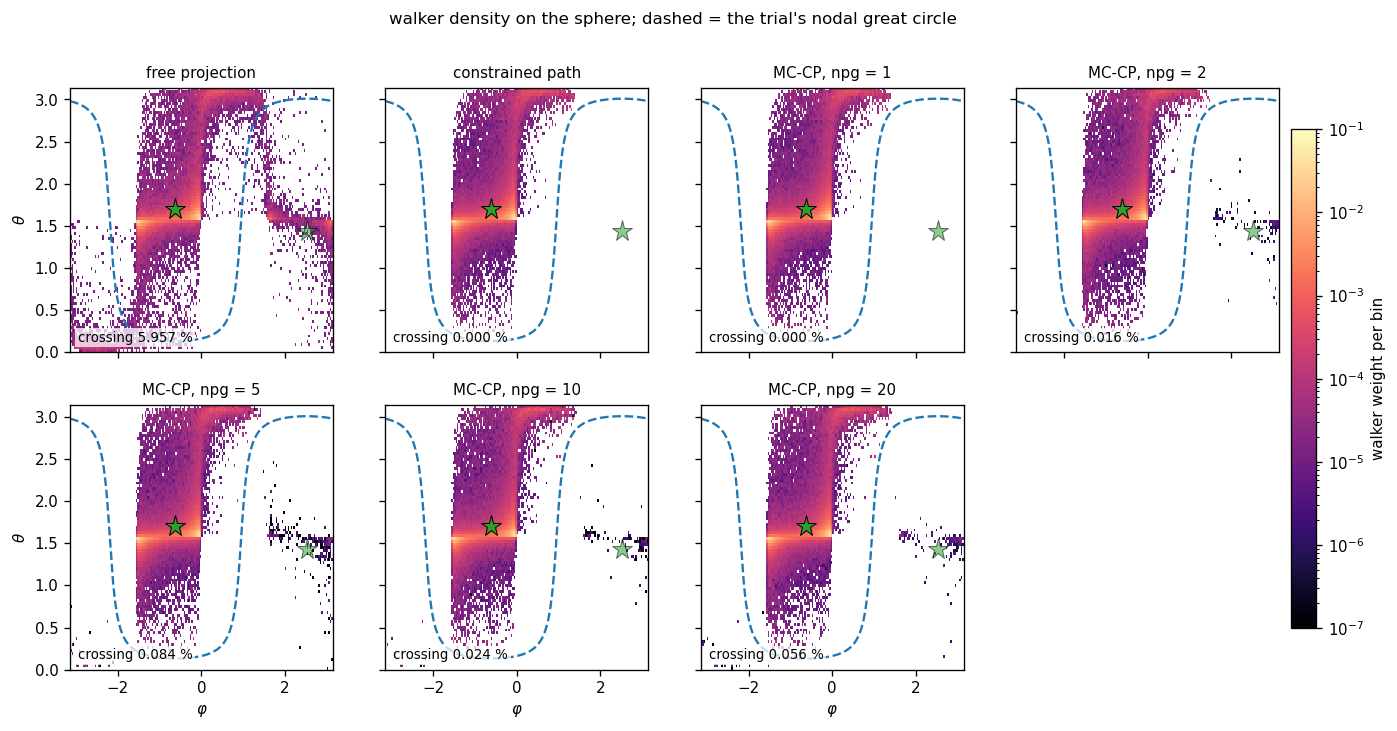

In [30]:

# every method on the same axes: free projection, CP, and MC-CP at each group size
panels = ([("free projection", fp.snaps_at(fp_taus[-1])), ("constrained path", cp_ref.snaps)]
          + [("MC-CP, npg = %d" % n, mc_runs[n].snaps) for n in GROUP_SIZES])

ncol = 4
nrow = int(np.ceil(len(panels) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.35 * ncol, 3.15 * nrow),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, (name, snaps) in zip(axes, panels):
    p_, t_, w_, o_ = walker_cloud(snaps)
    w_ = w_ / w_.sum()
    H_, _, _ = np.histogram2d(p_, t_, bins=[ep, et], weights=w_)
    pcm = ax.pcolormesh(ep, et, np.ma.masked_equal(H_, 0).T, cmap="magma", shading="auto",
                        norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e-1))
    ax.plot(phi_n, th_n, "--", color="C0", lw=1.4)
    ax.plot(ph_t, th_t, "*", ms=13, color="C2", mec="k", mew=0.6)
    ax.plot(ph_t - np.sign(ph_t) * np.pi, np.pi - th_t, "*", ms=13, color="C2",
            mec="k", mew=0.6, alpha=0.55)
    ax.set_title(name, fontsize=9)
    ax.text(0.03, 0.04, "crossing %.3f %%" % (100 * w_[o_ < 0].sum()),
            transform=ax.transAxes, fontsize=8, color="k",
            bbox=dict(fc="w", ec="none", alpha=0.75, pad=1.5))
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, np.pi)
for ax in axes[len(panels):]:
    ax.axis("off")
for ax in axes[(nrow - 1) * ncol:]:
    ax.set_xlabel(r"$\varphi$")
for r in range(nrow):
    axes[r * ncol].set_ylabel(r"$\theta$")
fig.colorbar(pcm, ax=axes.tolist(), fraction=0.02, pad=0.01,
             label="walker weight per bin")
fig.suptitle("walker density on the sphere; dashed = the trial's nodal great circle",
             fontsize=10)
plt.show()


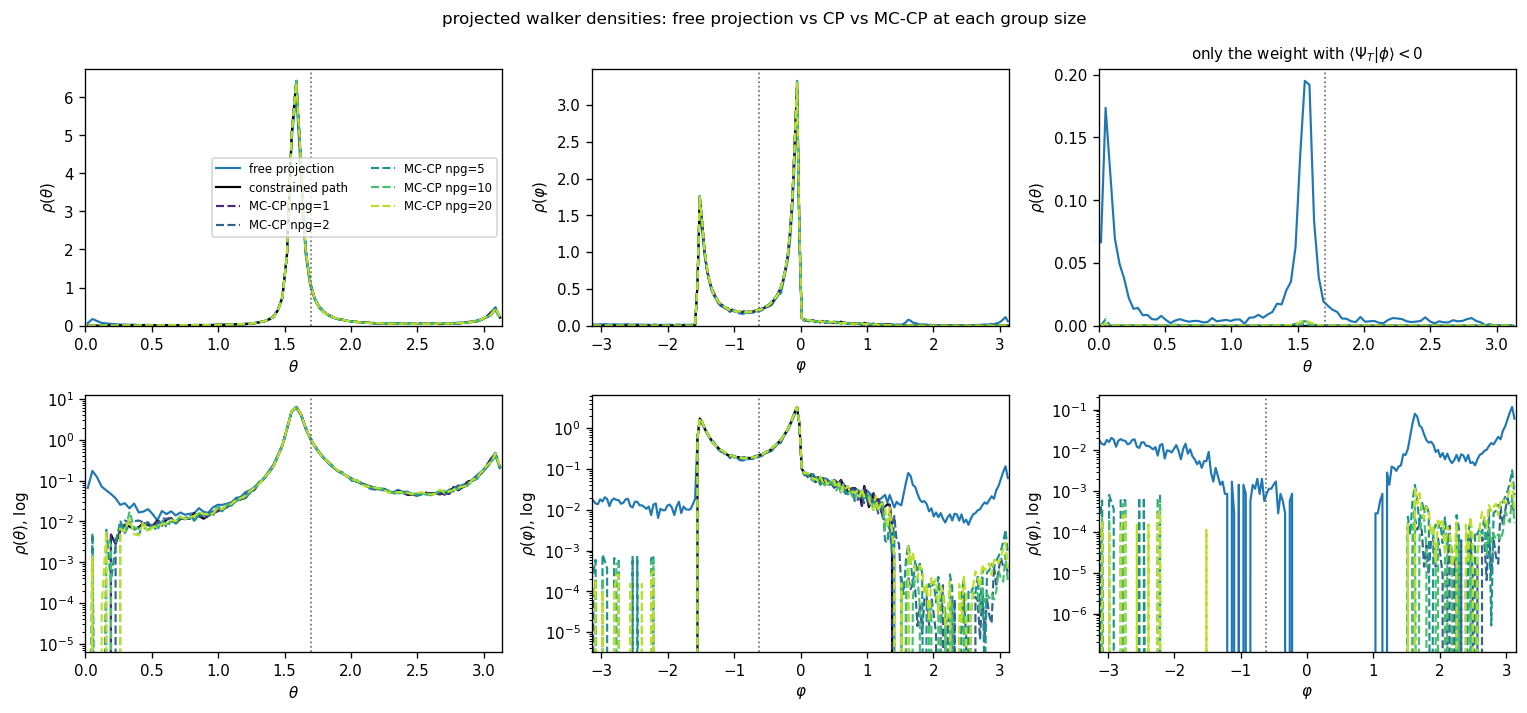

In [31]:
# the same populations projected on each angle (the other integrated out)
curves = [("free projection", fp.snaps_at(fp_taus[-1]), "C0", "-"),
          ("constrained path", cp_ref.snaps, "k", "-")]
for k, n in enumerate(GROUP_SIZES):
    curves.append(("MC-CP npg=%d" % n, mc_runs[n].snaps,
                   plt.cm.viridis(0.12 + 0.78 * k / max(1, len(GROUP_SIZES) - 1)), "--"))

fig, axes = plt.subplots(2, 3, figsize=(12.8, 6.0))
tops = np.zeros((2, 3))          # peak of each panel, for the log y-limits

for name, snaps, col, ls in curves:
    p_, t_, w_, o_ = walker_cloud(snaps)
    w_ = w_ / w_.sum()
    ht = np.histogram(t_, bins=et, weights=w_)[0] / dt_
    hp = np.histogram(p_, bins=ep, weights=w_)[0] / dp
    neg = o_ < 0
    ht_m = np.histogram(t_[neg], bins=et, weights=w_[neg])[0] / dt_
    hp_m = np.histogram(p_[neg], bins=ep, weights=w_[neg])[0] / dp
    for row in (0, 1):
        axes[row, 0].plot(ctr_t, ht, color=col, ls=ls, lw=1.3,
                          label=name if row == 0 else None)
        axes[row, 1].plot(ctr_p, hp, color=col, ls=ls, lw=1.3)
    axes[0, 2].plot(ctr_t, ht_m, color=col, ls=ls, lw=1.3)
    axes[1, 2].plot(ctr_p, hp_m, color=col, ls=ls, lw=1.3)
    tops[0, 0] = tops[1, 0] = max(tops[0, 0], ht.max())
    tops[0, 1] = tops[1, 1] = max(tops[0, 1], hp.max())
    tops[0, 2] = max(tops[0, 2], ht_m.max())
    tops[1, 2] = max(tops[1, 2], hp_m.max())

layout = ((r"\theta", th_t, (0, np.pi)), (r"\varphi", ph_t, (-np.pi, np.pi)),
          (r"\theta", th_t, (0, np.pi)))
for row in (0, 1):
    for col in (0, 1, 2):
        lab, mark, xlim = layout[col] if not (row == 1 and col == 2) else \
                          (r"\varphi", ph_t, (-np.pi, np.pi))
        ax = axes[row, col]
        ax.axvline(mark, color="0.4", lw=1.0, ls=":")
        ax.set_xlim(*xlim); ax.set_xlabel("$%s$" % lab)
        ax.set_ylabel(r"$\rho(%s)$" % lab + (", log" if row else ""))
        if row:
            # floor six decades under the peak: below that the curve is just bins
            # holding one walker, and the log axis turns them into noise spikes
            ax.set_yscale("log"); ax.set_ylim(1e-6 * tops[row, col], 2 * tops[row, col])
        else:
            ax.set_ylim(0, 1.05 * tops[row, col])

axes[0, 2].set_title(r"only the weight with $\langle\Psi_T|\phi\rangle<0$", fontsize=9)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle("projected walker densities: free projection vs CP vs MC-CP at each group size",
             fontsize=10)
fig.tight_layout(); plt.show()